In [13]:
# YOLO Segmentation (이미지 분할 - 단순한 bounding box(Detection)가 아닌, pixel별로 분석해서 이미지 분리)
# 객체 그대로 영역(mask)을 찾음

import os, cv2, numpy as np
from ultralytics import YOLO

IMG_PATH = "yolo_imgs/image1.jpg"
OUT_DIR = "seg_out"
os.makedirs(OUT_DIR, exist_ok=True)

im = cv2.imread(IMG_PATH)
assert im is not None, f"이미지 없음:{IMG_PATH}"

# 원본 이미지의 높이(H)와 너비(W)   -->>    mask를 resize하기 위해 필요
H, W = im.shape[:2]

model = YOLO("yolo11n-seg.pt")
res = model(im)[0]
imsi = res

# 탐지 박스 정보
print(imsi.boxes)
print()

# Segmentation 마스크 정보
print(imsi.masks)
# masks.data    : 개별 마스크 이미지 데이터
# masks.xy      : 객체 윤곽선 좌표

# 원본 이미지 위에 "바운딩 박스 + 클래스 라벨 + 신뢰도"를 마스크로 처리
# 현재는 sanity check(기본 검증)를 함.
# 기본적인 값/상태가 정상 범위인지 빠르게 확인한다
cv2.imwrite(os.path.join(OUT_DIR, "00_anno.jpg"), res.plot())

# segmentation 결과가 없는 경우
if res.masks is None or len(res.masks.data) == 0:
    print("mask 객체 X")
    raise SystemExit

# (N, height, width) float 텐서를 numpy 배열로 바꿈     -->>    모든 값이 0~1 사이값으로 변환
m_small = res.masks.data.cpu().numpy()
# print(m_small)

masks = np.stack([
    # cv2.INTER_NEARSET : 최근접 이웃 보간법 -->> 0.5보다 큰 값만 사용  -->>    이미지 흐림 방지
    cv2.resize(m, (W, H), cv2.INTER_NEAREST) > 0.5 for m in m_small
], axis=0)      # amsk를 모아 (N, H, W)배열로 만듦. mask는 최종적으로 N개의 bool 스택이 됨. masks.shape == (객체개수, 높이, 너비)

# mask preview (segmentation 전 단계)
mask_union = (masks.any(axis=0).astype(np.uint8)*255)                       # openCV에서 이미지 저장범위가 0~255
cv2.imwrite(os.path.join(OUT_DIR, "01_mask_preview.png"), mask_union)       # 단일 마스크 흑백 이미지로 저장






0: 416x640 2 persons, 20.1ms
Speed: 2.4ms preprocess, 20.1ms inference, 2.3ms postprocess per image at shape (1, 3, 416, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0.], device='cuda:0')
conf: tensor([0.8409, 0.7079], device='cuda:0')
data: tensor([[120.0181,   0.9432, 283.0374, 173.3571,   0.8409,   0.0000],
        [ 15.4300,  11.7173, 165.8862, 173.1279,   0.7079,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (175, 287)
shape: torch.Size([2, 6])
xywh: tensor([[201.5278,  87.1502, 163.0193, 172.4139],
        [ 90.6581,  92.4226, 150.4562, 161.4106]], device='cuda:0')
xywhn: tensor([[0.7022, 0.4980, 0.5680, 0.9852],
        [0.3159, 0.5281, 0.5242, 0.9223]], device='cuda:0')
xyxy: tensor([[120.0181,   0.9432, 283.0374, 173.3571],
        [ 15.4300,  11.7173, 165.8862, 173.1279]], device='cuda:0')
xyxyn: tensor([[0.4182, 0.0054, 0.9862, 0.9906],
        [0.0538, 0.0670, 0.5780, 0.9893]], device='cuda:0')

ultralytics.engine.resu

True

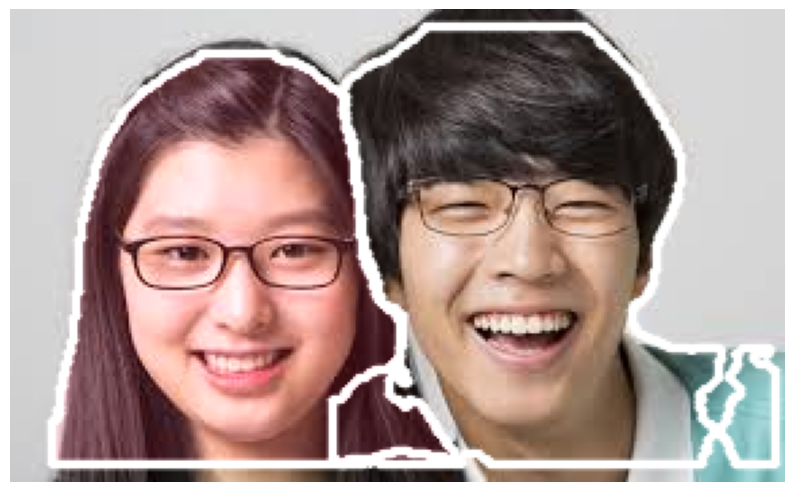

In [16]:
# 최종 Segmentation 결과 시각화 : Color overlay + 외곽선
# Segmentation은 이미지의 각 픽셀이 어떤 객체/영역에 속하는지 구분하는 작업이다.
# Detection이 객체의 위치를 사각형 박스(bounding box)로 찾는 것이라면,
# Segmentation은 객체의 실제 모양을 따라 픽셀 단위의 마스크(mask)를 만든다.
# 여기서는 각 객체(instance)의 마스크 영역에 색을 입히고,
# 외곽선을 그려서 원본 이미지 위에 겹쳐 보여준다.

def color(i):
    # 각 객체(instance)를 구분하기 위해 고유한 색상을 만든다.
    # i는 객체 번호이며, 서로 다른 계수를 곱한 뒤 256으로 나머지를 구해
    # OpenCV 이미지 색상 범위인 0~255 안의 값을 만든다.
    # OpenCV는 색상 순서가 RGB가 아니라 BGR이므로 (Blue, Green, Red) 순서로 반환한다.
    # 이 색상은 마스크 영역을 칠하거나 외곽선을 그릴 때 사용된다.
    return ((37 * i) % 256, (17 * i) % 256, (91 * i) % 256)


# 최종 합성용 캔버스
# 원본 이미지 im을 복사해서, 이 위에 segmentation 결과를 그린다.
# 원본을 직접 수정하지 않고 복사본을 사용하는 이유는
# 원본 이미지를 보존하면서 시각화 결과만 따로 만들기 위해서이다.
final = im.copy()


# im과 같은 크기의 빈 캔버스
# 각 픽셀 값이 0인 검정 이미지로 시작한다.
# 이후 객체 마스크 영역에만 색을 채워 넣고,
# 원본 이미지와 alpha blending 방식으로 합성한다.
blend = np.zeros_like(im)


# 각 instance에 대해서 색깔 채우기
# Instance segmentation에서는 이미지 안의 여러 객체를 각각 따로 구분한다.
# 예를 들어 사람 1명, 자동차 1대, 가방 1개가 있으면
# 각 객체마다 별도의 mask가 생성된다.
# 이 반복문에서는 각 mask를 하나씩 가져와 해당 객체 영역에 고유 색상을 칠한다.
for i, m in enumerate(masks):
    # 마스크 영역에 고유 색깔 채우기
    blend[m] = color(i)

    # 마스크 경계 추출
    # cv2.RETR_EXTERNAL : 가장 바깥쪽 외곽선
    # cv2.CHAIN_APPROX_SIMPLE : 꼭지점 단순화
    cnts, _ = cv2.findContours(
        (m.astype(np.uint8) * 255), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # 외곽선만 얹어, 경계 시각화
    cv2.drawContours(final, cnts, -1, (255, 255, 255), 2, cv2.LINE_AA)

# 반투명 합성
final = cv2.addWeighted(final, 1.0, blend, 0.45, 0.0)

# 최종 결과 저장
cv2.imwrite(os.path.join(OUT_DIR, "02_final_segmentation.png"), final)

# cv2.imshow("final segmentation : ", final)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
import matplotlib.pyplot as plt

# OpenCV는 BGR, matplotlib은 RGB 기준이라 색상 순서를 변환해서 출력
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()